# Notebook 07 — Baseline Models: Logistic Regression + Random Forest

**Inputs:** `outputs/train.parquet`, `outputs/val.parquet`, `outputs/class_weight_ratio.txt`  
**Outputs:** `outputs/scaler.pkl`, `outputs/lr_model.pkl`, `outputs/rf_model.pkl`, `outputs/model_comparison.csv`

**Leakage guardrails carried forward from Notebook 06:**
- Scaler is fit **only on train**, then applied to val (and later test) — no information from val/test leaks into the scaler statistics.
- GridSearchCV uses `PredefinedSplit` with the temporal val set — no random cross-validation folds that would mix train/val cohorts.
- Leaky columns (`last_expire_date`, `last_transaction`, `first_transaction`, `registration_init_time`) are already absent from the parquet files.

In [1]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, classification_report
)

ROOT    = Path("..").resolve()
OUTPUTS = ROOT / "outputs"

# Read class_weight_ratio
cw_text = (OUTPUTS / "class_weight_ratio.txt").read_text()
class_weight_ratio = float(
    next(l for l in cw_text.splitlines() if l.startswith("class_weight_ratio="))
    .split("=")[1]
)
print("class_weight_ratio:", round(class_weight_ratio, 4))

class_weight_ratio: 10.1183


## Section 1 — Preprocessing

In [2]:
def load_split(path):
    """Load parquet, clean column names (spaces/hyphens → underscores)."""
    df = pd.read_parquet(path)
    df.columns = [c.replace(" ", "_").replace("-", "_") for c in df.columns]
    return df

train = load_split(OUTPUTS / "train.parquet")
val   = load_split(OUTPUTS / "val.parquet")

TARGET       = "is_churn"
FEATURE_COLS = [c for c in train.columns if c not in ("msno", TARGET)]

X_train = train[FEATURE_COLS].values
y_train = train[TARGET].values
X_val   = val[FEATURE_COLS].values
y_val   = val[TARGET].values

print("Train : %s x %d  churn=%.2f%%" % (f"{len(X_train):,}", X_train.shape[1], y_train.mean()*100))
print("Val   : %s x %d  churn=%.2f%%" % (f"{len(X_val):,}",   X_val.shape[1],   y_val.mean()*100))
print("Features (%d): %s" % (len(FEATURE_COLS), FEATURE_COLS))

Train : 742,546 x 35  churn=8.92%
Val   : 103,142 x 35  churn=9.81%
Features (35): ['total_paid', 'avg_payment', 'max_payment', 'discount_rate', 'n_transactions', 'avg_plan_days', 'auto_renew_rate', 'cancel_rate', 'days_as_member', 'n_payment_methods', 'total_secs', 'avg_daily_secs', 'max_daily_secs', 'total_songs_played', 'completion_rate', 'skip_rate', 'unique_songs_ratio', 'active_days', 'days_since_last_log', 'city_freq_rank', 'age', 'membership_tenure', 'gender_male', 'gender_female', 'gender_unknown', 'reg_via_4', 'reg_via_3', 'reg_via_9', 'reg_via_7', 'reg_via_11', 'reg_via_other', 'segment_At_Risk', 'segment_Casual_Listeners', 'segment_Dormant', 'segment_Power_Users']


In [3]:
# Fit scaler on train ONLY — val/test are transformed but never used to fit
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

joblib.dump(scaler, OUTPUTS / "scaler.pkl")
print("Scaler fit on train (%s rows). Saved: outputs/scaler.pkl" % f"{len(X_train):,}")
print("Val transformed using train statistics only — no leakage.")

Scaler fit on train (742,546 rows). Saved: outputs/scaler.pkl
Val transformed using train statistics only — no leakage.


## Section 2 — Logistic Regression

In [4]:
t0 = time.time()
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_sc, y_train)
lr_train_time = time.time() - t0

lr_proba = lr.predict_proba(X_val_sc)[:, 1]
lr_pred  = lr.predict(X_val_sc)

lr_auc  = roc_auc_score(y_val, lr_proba)
lr_f1   = f1_score(y_val, lr_pred)
lr_prec = precision_score(y_val, lr_pred)
lr_rec  = recall_score(y_val, lr_pred)
lr_acc  = accuracy_score(y_val, lr_pred)

print("Logistic Regression — Val Metrics")
print("-" * 40)
print("  ROC-AUC   : %.4f" % lr_auc)
print("  F1        : %.4f" % lr_f1)
print("  Precision : %.4f" % lr_prec)
print("  Recall    : %.4f" % lr_rec)
print("  Accuracy  : %.4f" % lr_acc)
print("  Train time: %.1fs" % lr_train_time)
print()
print(classification_report(y_val, lr_pred, target_names=["Not Churn", "Churn"]))

C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression — Val Metrics
----------------------------------------
  ROC-AUC   : 0.9090
  F1        : 0.5269
  Precision : 0.3759
  Recall    : 0.8806
  Accuracy  : 0.8449
  Train time: 1.7s

              precision    recall  f1-score   support

   Not Churn       0.98      0.84      0.91     93023
       Churn       0.38      0.88      0.53     10119

    accuracy                           0.84    103142
   macro avg       0.68      0.86      0.72    103142
weighted avg       0.93      0.84      0.87    103142



In [5]:
# Top 10 positive and top 10 negative coefficients
coef = lr.coef_[0]
coef_df = pd.DataFrame({"feature": FEATURE_COLS, "coefficient": coef})
coef_df = coef_df.sort_values("coefficient", ascending=False)

top10_pos = coef_df.head(10)
top10_neg = coef_df.tail(10).sort_values("coefficient")

print("Top 10 features pushing toward CHURN (positive coefficients):")
for _, row in top10_pos.iterrows():
    print("  %+.4f  %s" % (row["coefficient"], row["feature"]))

print()
print("Top 10 features pushing toward RETENTION (negative coefficients):")
for _, row in top10_neg.iterrows():
    print("  %+.4f  %s" % (row["coefficient"], row["feature"]))

Top 10 features pushing toward CHURN (positive coefficients):
  +1.1404  cancel_rate
  +0.8698  avg_plan_days
  +0.7710  days_since_last_log
  +0.4650  total_paid
  +0.2412  membership_tenure
  +0.2383  reg_via_7
  +0.1604  reg_via_3
  +0.1280  segment_Casual_Listeners
  +0.1106  segment_At_Risk
  +0.0955  segment_Power_Users

Top 10 features pushing toward RETENTION (negative coefficients):
  -1.0669  auto_renew_rate
  -0.4994  avg_payment
  -0.3960  segment_Dormant
  -0.2211  days_as_member
  -0.1500  n_payment_methods
  -0.1100  active_days
  -0.1010  skip_rate
  -0.0690  avg_daily_secs
  -0.0557  gender_unknown
  -0.0517  n_transactions


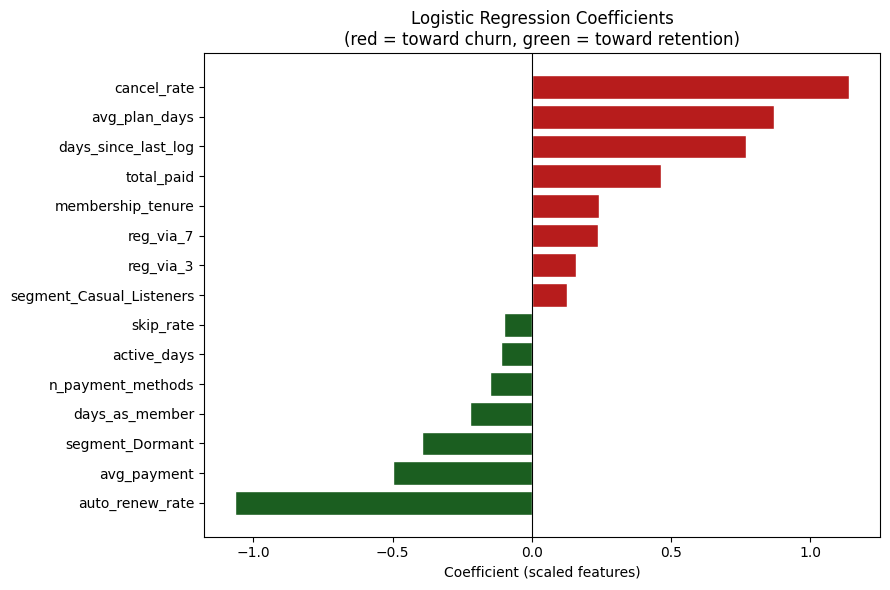

Saved: outputs/07_lr_coefficients.png


In [6]:
# Coefficient chart
top15 = pd.concat([coef_df.head(8), coef_df.tail(7)]).drop_duplicates()
top15 = top15.sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#B71C1C" if v > 0 else "#1B5E20" for v in top15["coefficient"]]
ax.barh(top15["feature"], top15["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (scaled features)")
ax.set_title("Logistic Regression Coefficients\n(red = toward churn, green = toward retention)")
plt.tight_layout()
plt.savefig(OUTPUTS / "07_lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/07_lr_coefficients.png")

## Section 3 — Random Forest

GridSearchCV uses `PredefinedSplit` to evaluate each parameter combination on the temporal val set instead of random cross-validation folds. This preserves the train/val temporal boundary.

In [7]:
# Combine train + val for GridSearchCV, but tell sklearn which rows are val
X_tv = np.vstack([X_train_sc, X_val_sc])
y_tv = np.concatenate([y_train, y_val])

# -1 = always train in this fold, 0 = validation fold 0
split_idx = np.concatenate([
    np.full(len(X_train_sc), -1),
    np.zeros(len(X_val_sc), dtype=int)
])
ps = PredefinedSplit(test_fold=split_idx)
print("PredefinedSplit: 1 fold | train=%s  val=%s" % (f"{len(X_train_sc):,}", f"{len(X_val_sc):,}"))

param_grid = {
    "n_estimators":    [100, 300],
    "max_depth":       [5, 10, None],
    "min_samples_leaf":[1, 5, 20],
    "class_weight":    ["balanced"],
}
n_combos = 2 * 3 * 3 * 1
print("Parameter combinations: %d" % n_combos)
print("Note: GridSearch trains each combination once on the predefined split.")
print("Running ... (this may take several minutes)")

PredefinedSplit: 1 fold | train=742,546  val=103,142
Parameter combinations: 18
Note: GridSearch trains each combination once on the predefined split.
Running ... (this may take several minutes)


In [8]:
t0 = time.time()

gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=2),
    param_grid=param_grid,
    cv=ps,
    scoring="roc_auc",
    n_jobs=1,      # sequential to avoid OOM on 12.5 GB machine
    verbose=1,
    refit=False,   # we refit manually below with best params
)
gs.fit(X_tv, y_tv)

gs_time = time.time() - t0
print("\nGridSearch done in %.1f min" % (gs_time / 60))
print("Best params : ", gs.best_params_)
print("Best val AUC: %.4f" % gs.best_score_)

Fitting 1 folds for each of 18 candidates, totalling 18 fits



GridSearch done in 36.7 min
Best params :  {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
Best val AUC: 0.9774


In [9]:
# Refit best RF on full train set
t0 = time.time()
best_params = {k: v for k, v in gs.best_params_.items()}
rf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rf_train_time = time.time() - t0

rf_proba = rf.predict_proba(X_val_sc)[:, 1]
rf_pred  = rf.predict(X_val_sc)

rf_auc  = roc_auc_score(y_val, rf_proba)
rf_f1   = f1_score(y_val, rf_pred)
rf_prec = precision_score(y_val, rf_pred)
rf_rec  = recall_score(y_val, rf_pred)
rf_acc  = accuracy_score(y_val, rf_pred)

print("Random Forest (best params) — Val Metrics")
print("-" * 45)
print("  ROC-AUC   : %.4f" % rf_auc)
print("  F1        : %.4f" % rf_f1)
print("  Precision : %.4f" % rf_prec)
print("  Recall    : %.4f" % rf_rec)
print("  Accuracy  : %.4f" % rf_acc)
print("  Train time: %.1fs (refit on train only)" % rf_train_time)
print()
print(classification_report(y_val, rf_pred, target_names=["Not Churn", "Churn"]))

Random Forest (best params) — Val Metrics
---------------------------------------------
  ROC-AUC   : 0.9774
  F1        : 0.7998
  Precision : 0.7747
  Recall    : 0.8265
  Accuracy  : 0.9594
  Train time: 89.3s (refit on train only)

              precision    recall  f1-score   support

   Not Churn       0.98      0.97      0.98     93023
       Churn       0.77      0.83      0.80     10119

    accuracy                           0.96    103142
   macro avg       0.88      0.90      0.89    103142
weighted avg       0.96      0.96      0.96    103142



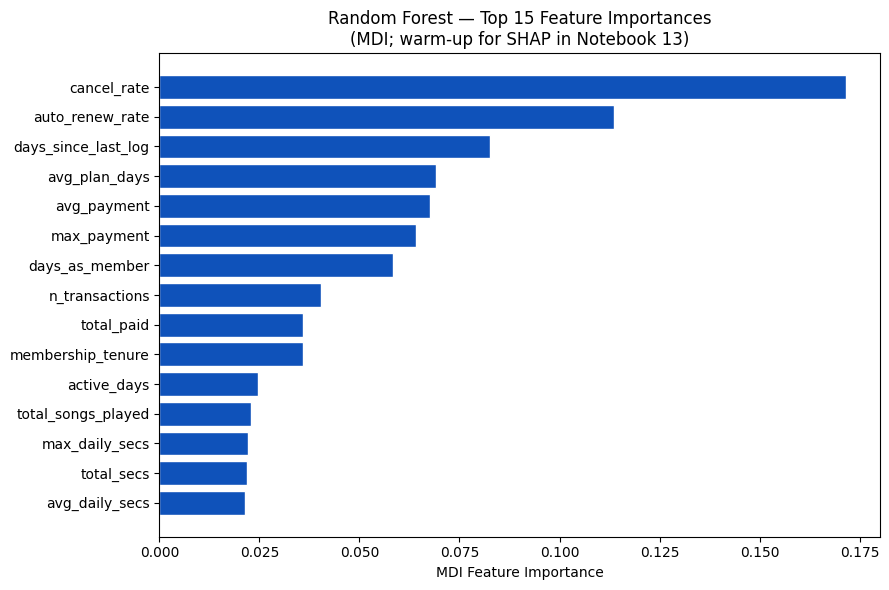

Saved: outputs/07_rf_feature_importance.png

Top 15 features by MDI importance:
  0.1715  cancel_rate
  0.1135  auto_renew_rate
  0.0826  days_since_last_log
  0.0692  avg_plan_days
  0.0676  avg_payment
  0.0641  max_payment
  0.0585  days_as_member
  0.0405  n_transactions
  0.0358  total_paid
  0.0358  membership_tenure
  0.0247  active_days
  0.0228  total_songs_played
  0.0222  max_daily_secs
  0.0219  total_secs
  0.0214  avg_daily_secs


In [10]:
# RF Feature Importance — top 15 (MDI)
fi = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="#0F52BA", edgecolor="white")
ax.set_xlabel("MDI Feature Importance")
ax.set_title("Random Forest — Top 15 Feature Importances\n(MDI; warm-up for SHAP in Notebook 13)")
plt.tight_layout()
plt.savefig(OUTPUTS / "07_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/07_rf_feature_importance.png")

print("\nTop 15 features by MDI importance:")
for _, row in fi.iterrows():
    print("  %.4f  %s" % (row["importance"], row["feature"]))

## Section 4 — Model Comparison Table

In [11]:
comparison = pd.DataFrame([
    {
        "Model":         "Logistic Regression",
        "Val ROC-AUC":   round(lr_auc,  4),
        "Val F1":        round(lr_f1,   4),
        "Val Precision": round(lr_prec, 4),
        "Val Recall":    round(lr_rec,  4),
        "Train Time (s)": round(lr_train_time, 1),
    },
    {
        "Model":         "Random Forest",
        "Val ROC-AUC":   round(rf_auc,  4),
        "Val F1":        round(rf_f1,   4),
        "Val Precision": round(rf_prec, 4),
        "Val Recall":    round(rf_rec,  4),
        "Train Time (s)": round(rf_train_time, 1),
    },
])

print(comparison.to_string(index=False))
comparison.to_csv(OUTPUTS / "model_comparison.csv", index=False)
print("\nSaved: outputs/model_comparison.csv")

              Model  Val ROC-AUC  Val F1  Val Precision  Val Recall  Train Time (s)
Logistic Regression       0.9090  0.5269         0.3759      0.8806             1.7
      Random Forest       0.9774  0.7998         0.7747      0.8265            89.3



Saved: outputs/model_comparison.csv


## Section 5 — Save Models

In [12]:
joblib.dump(lr, OUTPUTS / "lr_model.pkl")
joblib.dump(rf, OUTPUTS / "rf_model.pkl")
print("Saved: outputs/lr_model.pkl")
print("Saved: outputs/rf_model.pkl")
print()
print("Summary")
print("-" * 50)
print("  Scaler         : outputs/scaler.pkl  (fit on train only)")
print("  LR val AUC     : %.4f" % lr_auc)
print("  RF val AUC     : %.4f" % rf_auc)
print("  RF best params : %s" % best_params)
print("  Feature cols   : %d  (leaky cols excluded)" % len(FEATURE_COLS))

Saved: outputs/lr_model.pkl
Saved: outputs/rf_model.pkl

Summary
--------------------------------------------------
  Scaler         : outputs/scaler.pkl  (fit on train only)
  LR val AUC     : 0.9090
  RF val AUC     : 0.9774
  RF best params : {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
  Feature cols   : 35  (leaky cols excluded)
